In [1]:
pip install skimpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 46.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 6.29.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible

In [2]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import lightgbm as lgb
import warnings
from itertools import combinations
import plotly.express as px
from matplotlib.pyplot import figure
from skimpy import skim
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy
from sklearn.cluster import DBSCAN
from itertools import product
from sklearn.metrics import silhouette_score
import warnings
# Disable all warnings
warnings.filterwarnings ('ignore')


In [4]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 200    │ │ int64       │ 4     │                                                          │
│ │ Number of columns │ 5      │ │ string      │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                   ┃ NA  ┃ NA %  ┃ mean   ┃ sd     ┃ p0  ┃ p25    ┃ p50    ┃ p75    ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ CustomerID               │   0 │     0 │  100.5 │  57.88 │   1 │  50.75 │  100.5 │  150.2 │   200 │ ██████ │  │
│ │ Age                      │   0 │     0 │  38.85 │  13.97 │  18 │  28.75 │     36 │     49 │    70 │ ▆█▄▅▃▂ │  │
│ │ Annual Income (k$)       │   0 │     0 │  60.56 │  26.26 │  15 │   41.5 │   61.5 │     78 │   137 │ ▅▇█▅▂▁ │  │
│ │ Spending Score (1-100)   │   0 │     0 │   50.2 │  25.82 │   1 │  34.75 │     50 │     73 │    99 │ ▅▃█▇▅▄ │  │
│ └──────────────────────────┴─────┴───────┴────────┴────────┴─────┴────────┴────────┴────────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column  ┃ NA  ┃ NA %  ┃ shortest  ┃ longest  ┃ min    ┃ max  ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ Gender  │   0 │     0 │ Male      │ Female   │ Female │ Male │          5.12 │             1 │         200 │  │
│ └─────────┴─────┴───────┴───────────┴──────────┴────────┴──────┴───────────────┴───────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
df.dtypes

,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [11]:
plt.style.use('fivethirtyeight')

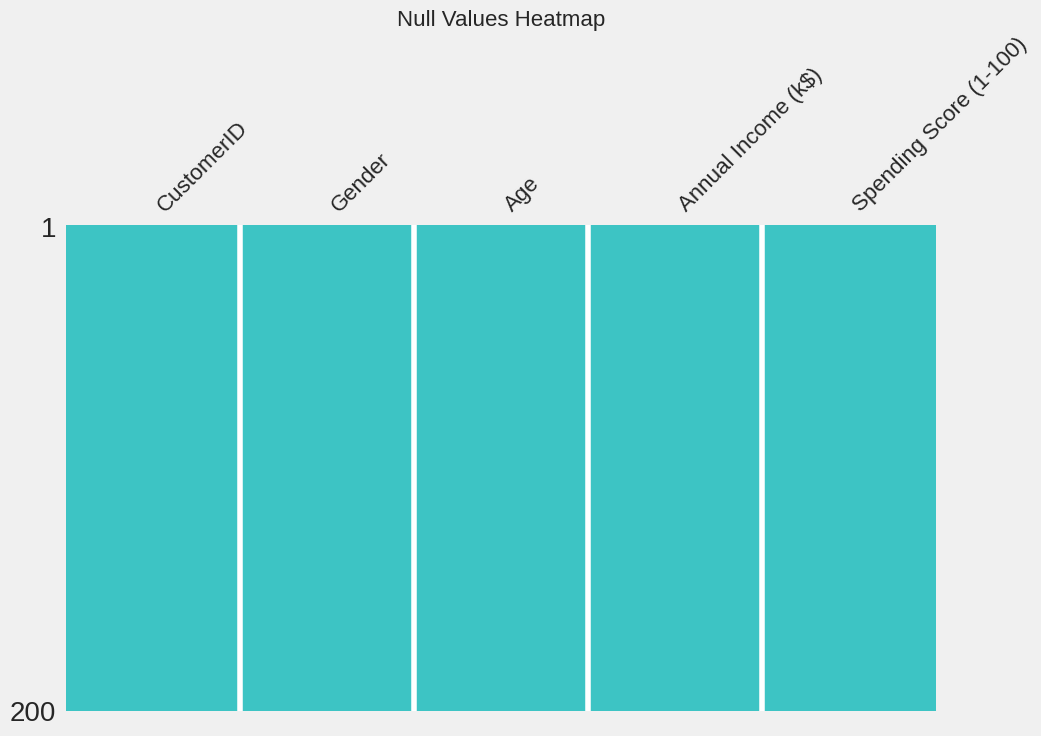

In [12]:
import missingno as msno
msno.matrix(df, figsize=(10, 6), sparkline=False, color=(0.24, 0.77, 0.77))
plt.title('Null Values Heatmap', fontsize=16)
plt.show()

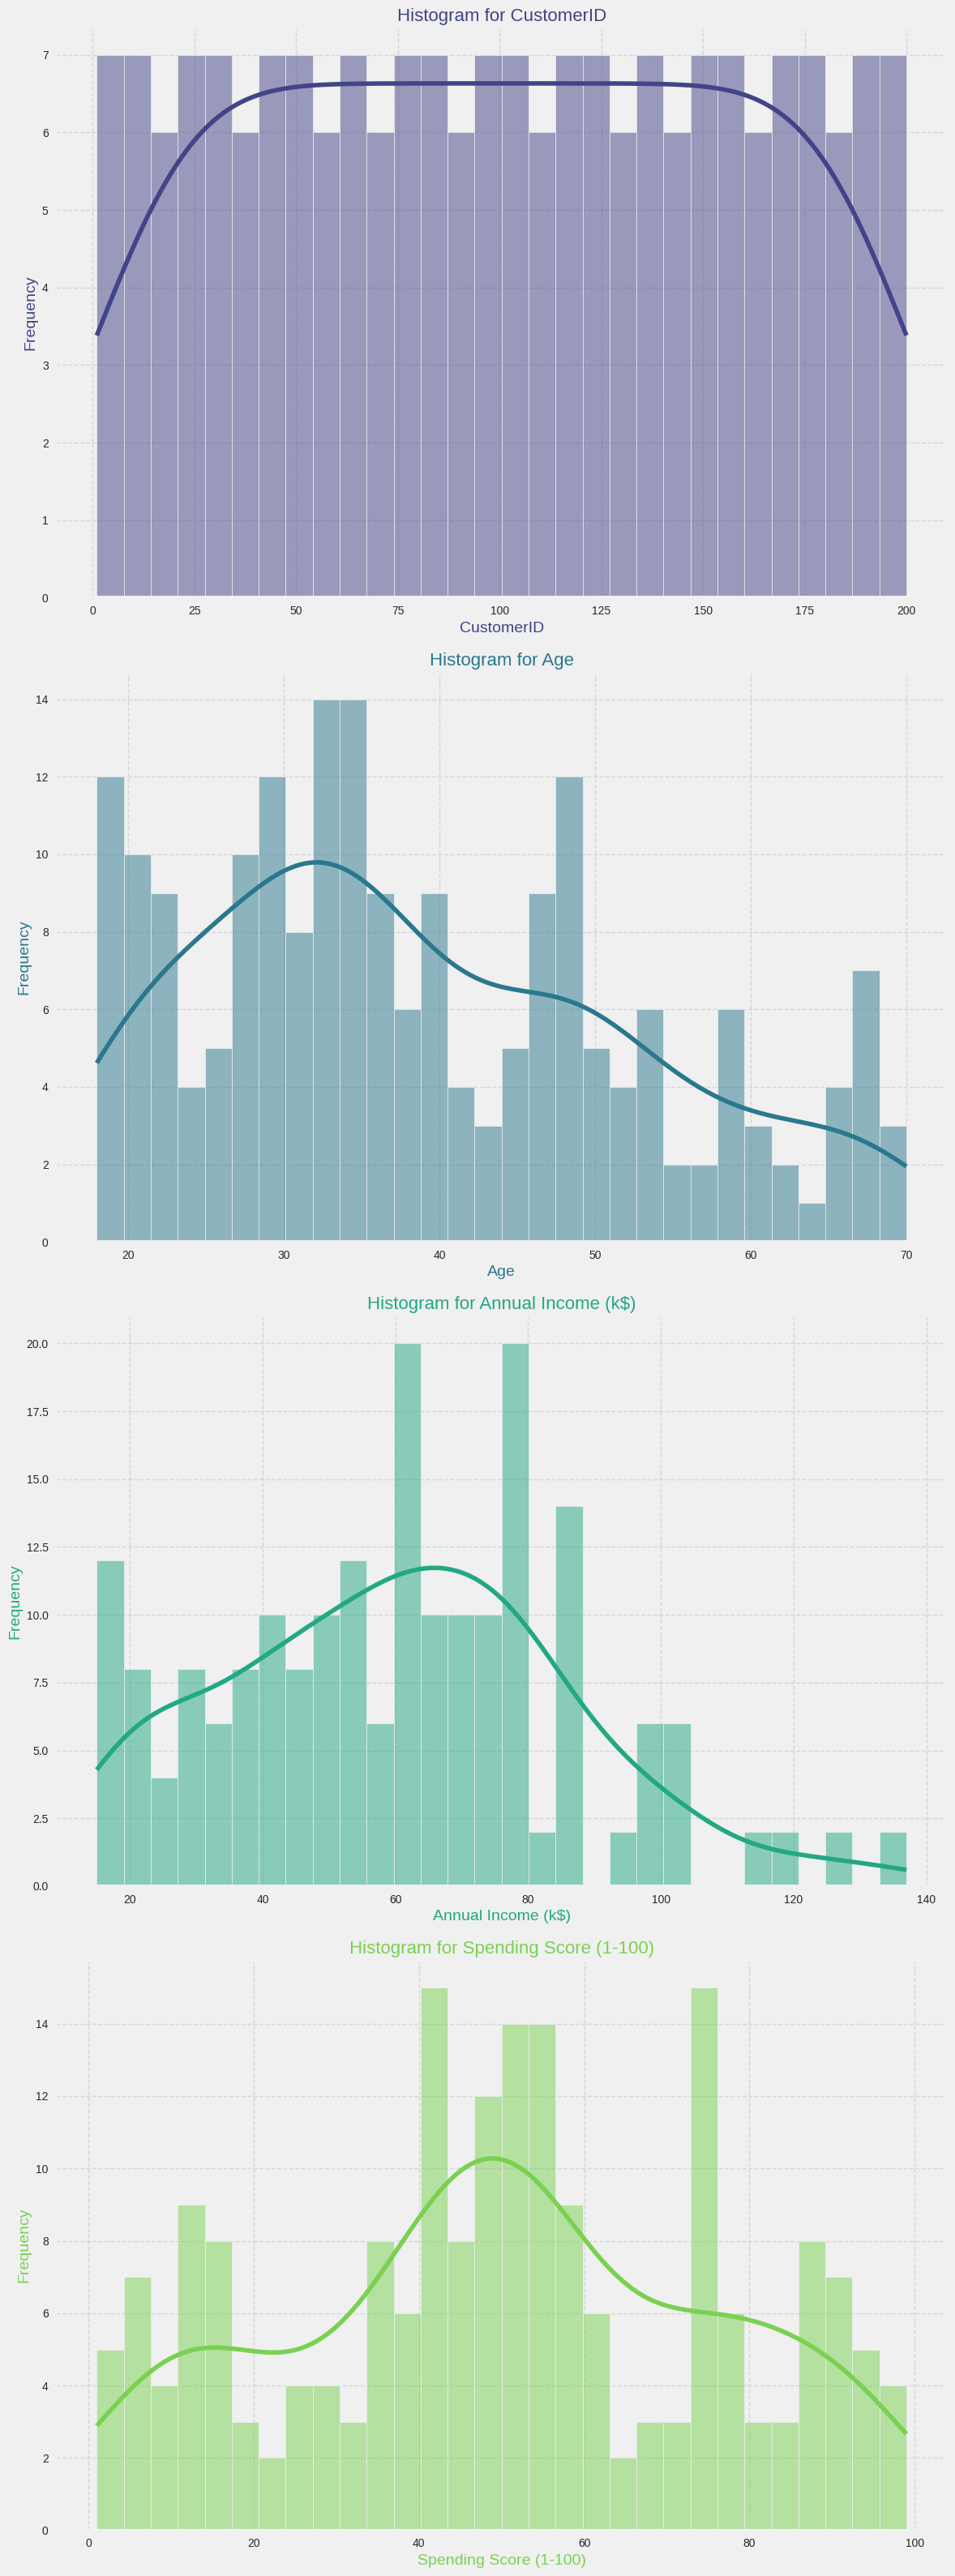

In [13]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(12, 8 * len(num_cols)))
colors = sns.color_palette("viridis", n_colors=len(num_cols))
for i, (col, color) in enumerate(zip(num_cols, colors)):
    sns.histplot(data=df, x=col, kde=True, color=color, ax=axes[i], bins=30)
    axes[i].set_title(f'Histogram for {col}', fontsize=16, color=color)
    axes[i].set_xlabel(col, fontsize=14, color=color)
    axes[i].set_ylabel('Frequency', fontsize=14, color=color)
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

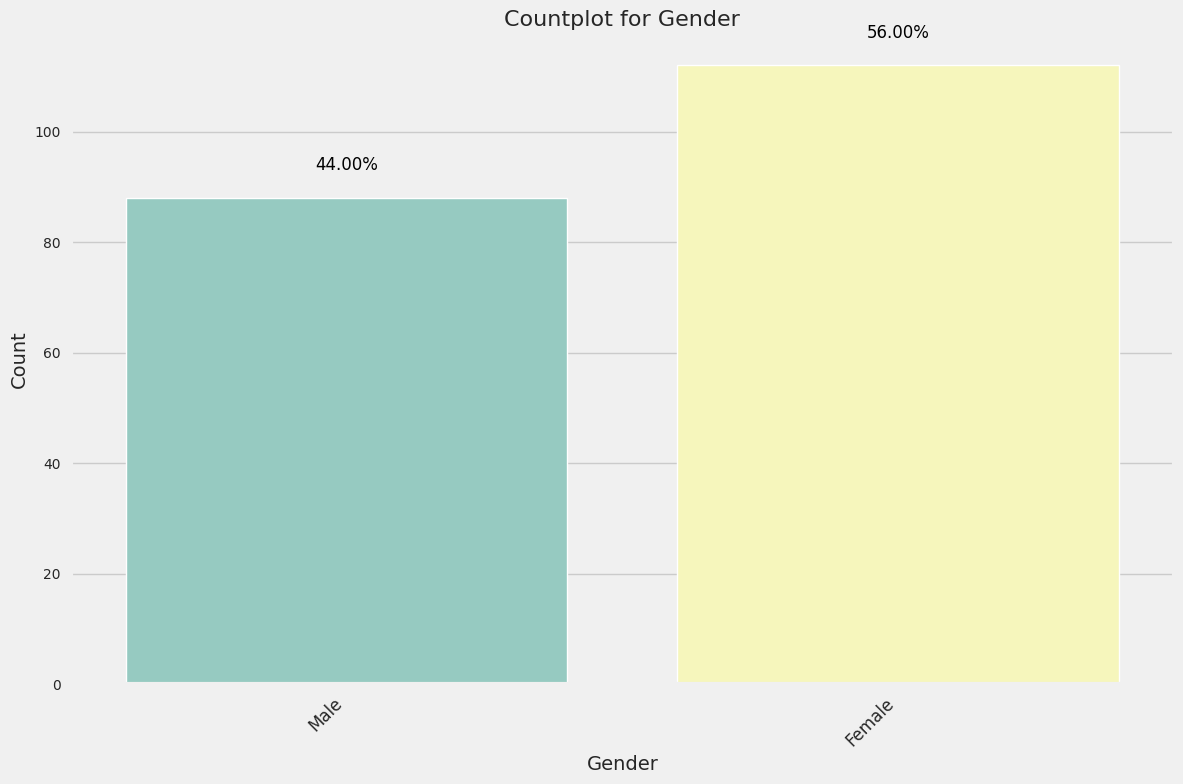

In [14]:
def create_countplots(df):
    obj_cols = df.select_dtypes(include=['object']).columns

    fig, axes = plt.subplots(nrows=len(obj_cols), ncols=1, figsize=(12, 8 * len(obj_cols)))

    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]

    for i, col in enumerate(obj_cols):
        sns.set_theme(style="whitegrid")
        ax = sns.countplot(data=df, x=col, palette="Set3", ax=axes[i])
        ax.set_title(f'Countplot for {col}', fontsize=16)
        ax.set_xlabel(col, fontsize=14)
        ax.set_ylabel('Count', fontsize=14)

        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=12)

        total_count = len(df)
        for p in ax.patches:
            percent = (p.get_height() / total_count) * 100
            ax.annotate(f'{percent:.2f}%', (p.get_x() + p.get_width() / 2, p.get_height() + 5),
                        ha='center', fontsize=12, color='black')

    plt.tight_layout()
    plt.show()

create_countplots(df)

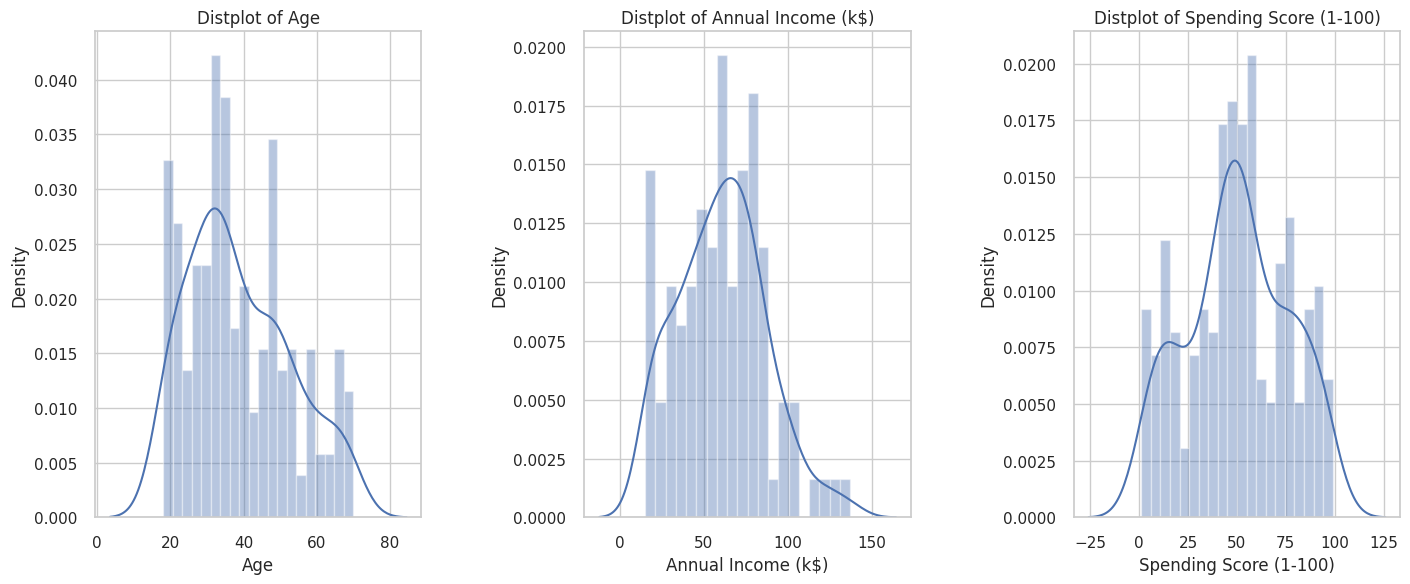

In [15]:
plt.figure(1 , figsize = (15 , 6))
n = 0
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace =0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 20)
    plt.title('Distplot of {}'.format(x))
plt.show()

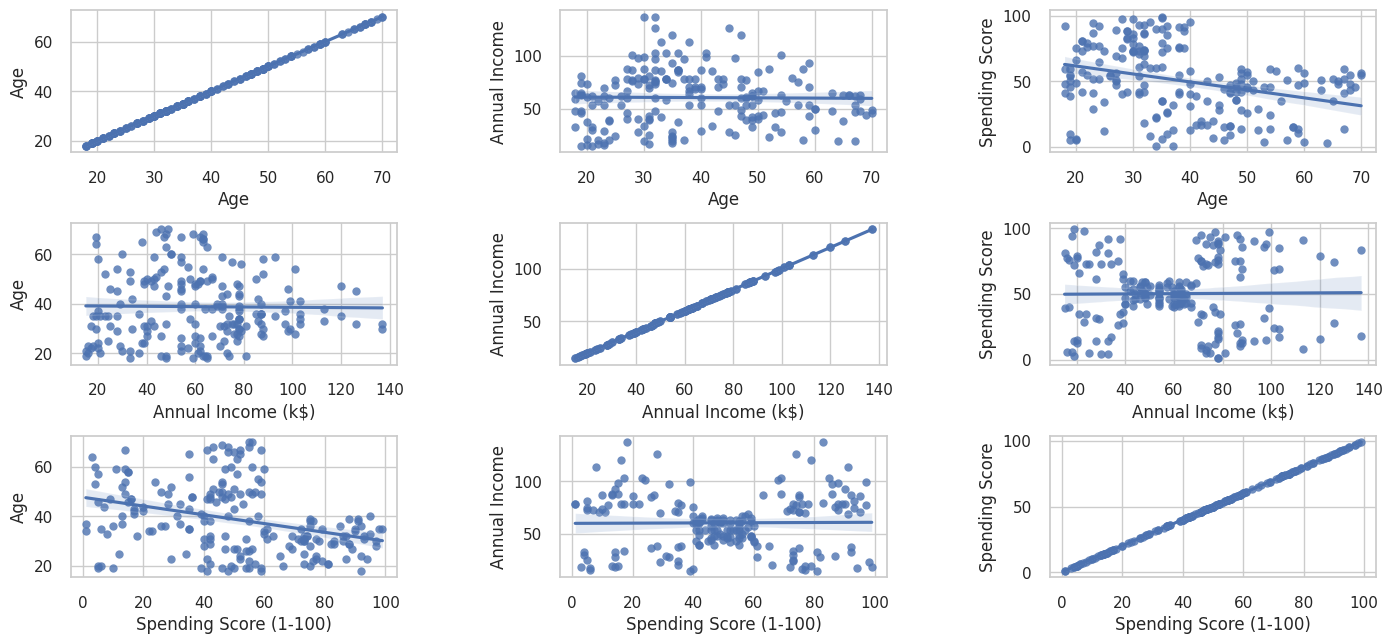

In [16]:
plt.figure(1 , figsize = (15 , 7))
n = 0
for x in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    for y in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
        n += 1
        plt.subplot(3 , 3 , n)
        plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
        sns.regplot(x = x , y = y , data = df)
        plt.ylabel(y.split()[0]+' '+y.split()[1] if len(y.split()) > 1 else y )
plt.show()

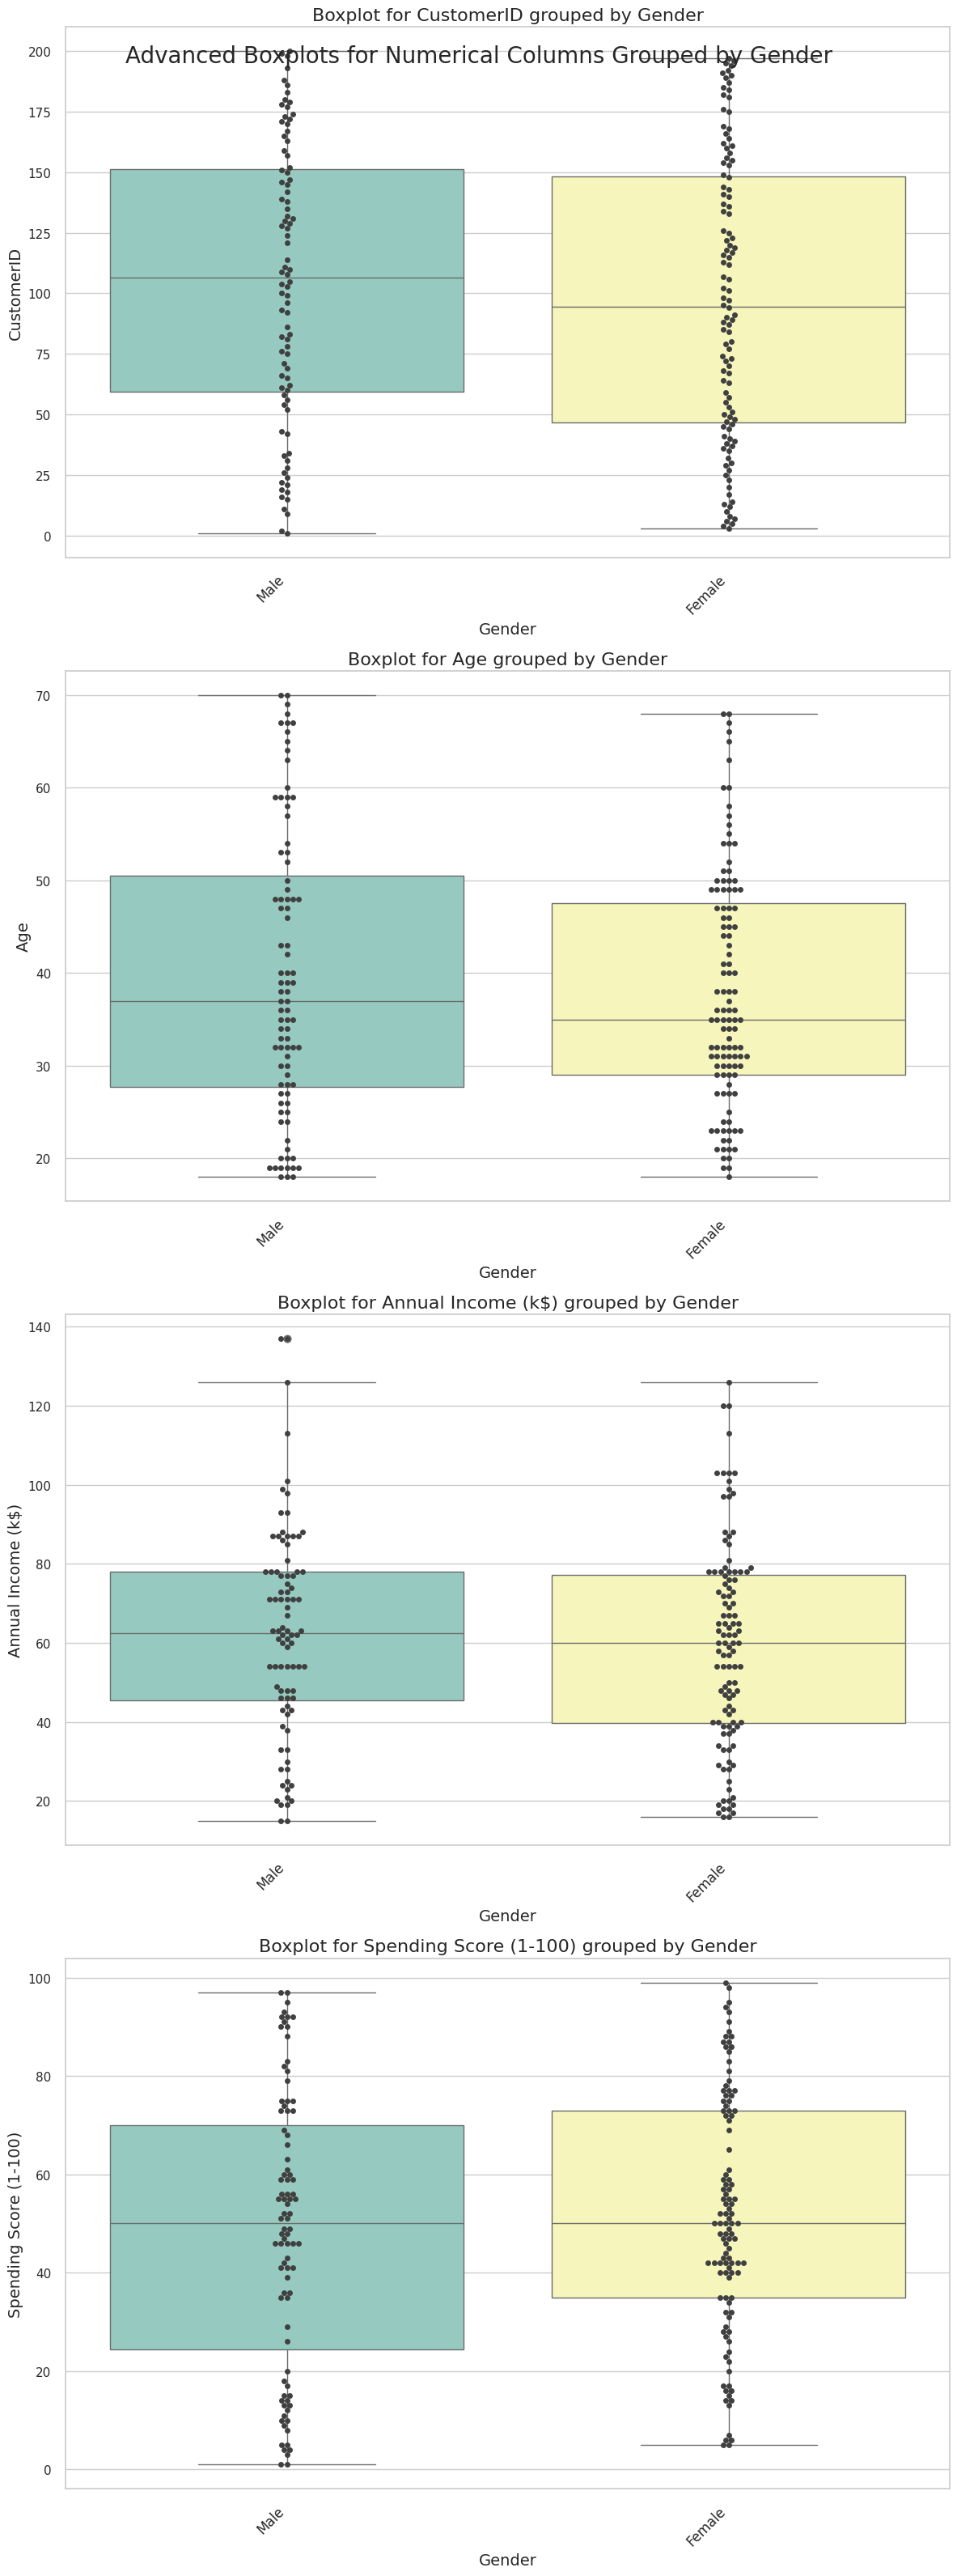

In [17]:
def create_boxplots(df, categorical_column):
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    fig, axes = plt.subplots(nrows=len(num_cols), ncols=1, figsize=(12, 8 * len(num_cols)))
    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]
    for i, col in enumerate(num_cols):
        sns.set_theme(style="whitegrid")  # Set Seaborn theme for better aesthetics
        ax = sns.boxplot(data=df, y=col, x=categorical_column, ax=axes[i], palette="Set3")
        ax.set_title(f'Boxplot for {col} grouped by {categorical_column}', fontsize=16)
        ax.set_xlabel(categorical_column, fontsize=14)
        ax.set_ylabel(col, fontsize=14)
        sns.swarmplot(data=df, x=categorical_column, y=col, color=".25", ax=axes[i])
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=12)
    plt.tight_layout()
    plt.suptitle(f'Advanced Boxplots for Numerical Columns Grouped by {categorical_column}', fontsize=20)
    plt.show()

create_boxplots(df, "Gender")

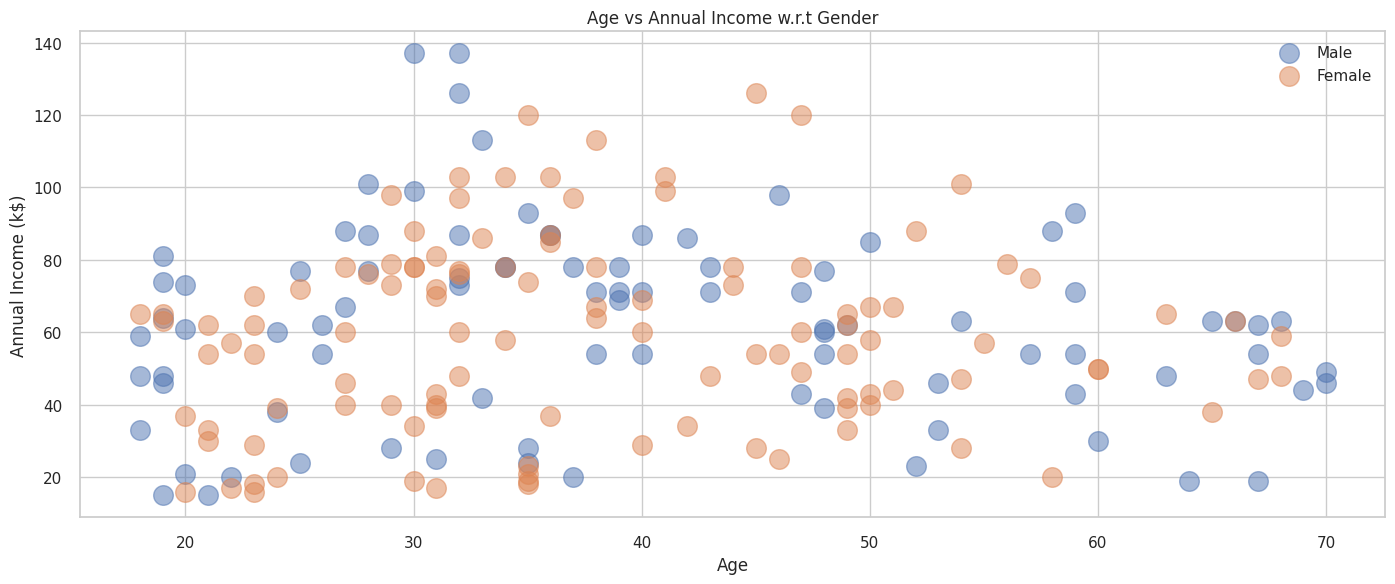

In [18]:
plt.figure(1 , figsize = (15 , 6))
for gender in ['Male' , 'Female']:
    plt.scatter(x = 'Age' , y = 'Annual Income (k$)' , data = df[df['Gender'] == gender] ,
                s = 200 , alpha = 0.5 , label = gender)
plt.xlabel('Age'), plt.ylabel('Annual Income (k$)')
plt.title('Age vs Annual Income w.r.t Gender')
plt.legend()
plt.show()

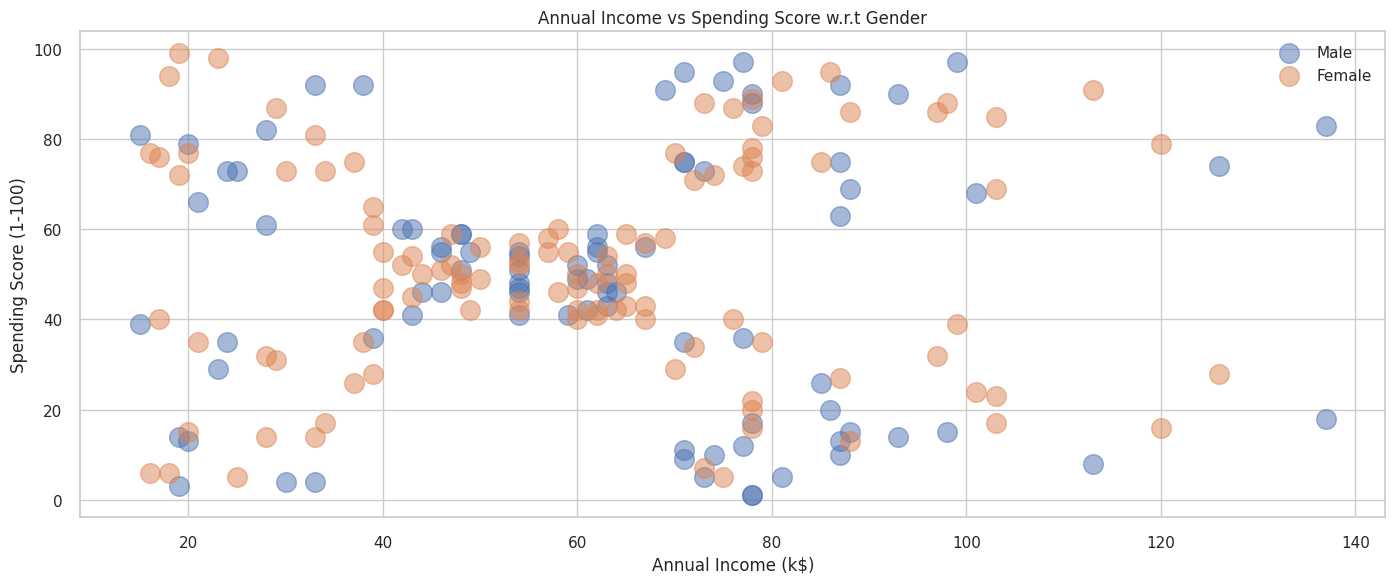

In [19]:
plt.figure(1 , figsize = (15 , 6))
for gender in ['Male' , 'Female']:
    plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)' ,
                data = df[df['Gender'] == gender] ,s = 200 , alpha = 0.5 , label = gender)
plt.xlabel('Annual Income (k$)'), plt.ylabel('Spending Score (1-100)')
plt.title('Annual Income vs Spending Score w.r.t Gender')
plt.legend()
plt.show()

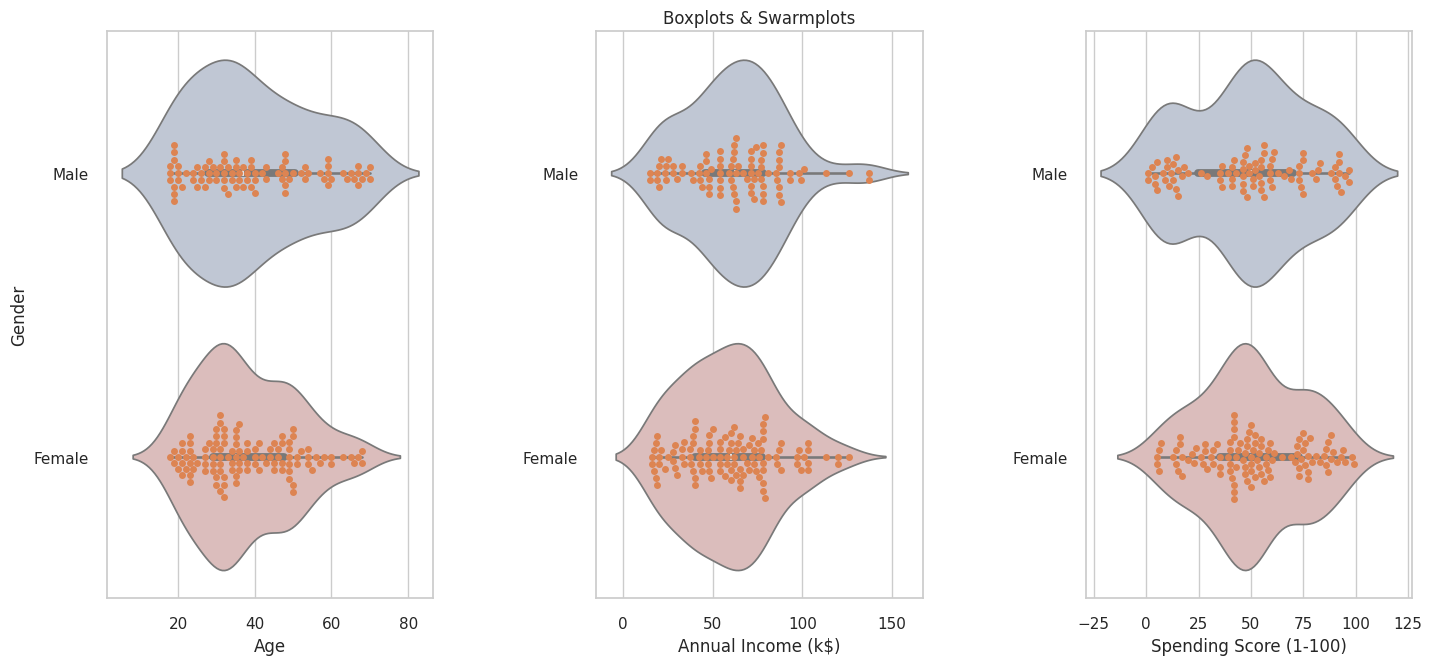

In [20]:
plt.figure(1 , figsize = (15 , 7))
n = 0
for cols in ['Age' , 'Annual Income (k$)' , 'Spending Score (1-100)']:
    n += 1
    plt.subplot(1 , 3 , n)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.violinplot(x = cols , y = 'Gender' , data = df , palette = 'vlag')
    sns.swarmplot(x = cols , y = 'Gender' , data = df)
    plt.ylabel('Gender' if n == 1 else '')
    plt.title('Boxplots & Swarmplots' if n == 2 else '')
plt.show()

In [21]:
def one_hot_encode_columns(df, columns_to_encode):
    df_encoded = pd.get_dummies(df, columns=columns_to_encode, prefix=columns_to_encode)
    df_encoded = df_encoded.astype(int)
    return df_encoded


df2 = one_hot_encode_columns(df, columns_to_encode=['Gender'])


In [22]:
df_train=df2.drop('CustomerID',axis=1)
df_train.corr()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
Age,1.000000,-0.012398,-0.327227,-0.060867,0.060867
Annual Income (k$),-0.012398,1.000000,0.009903,-0.056410,0.056410
Spending Score (1-100),-0.327227,0.009903,1.000000,0.058109,-0.058109
Gender_Female,-0.060867,-0.056410,0.058109,1.000000,-1.000000
Gender_Male,0.060867,0.056410,-0.058109,-1.000000,1.000000


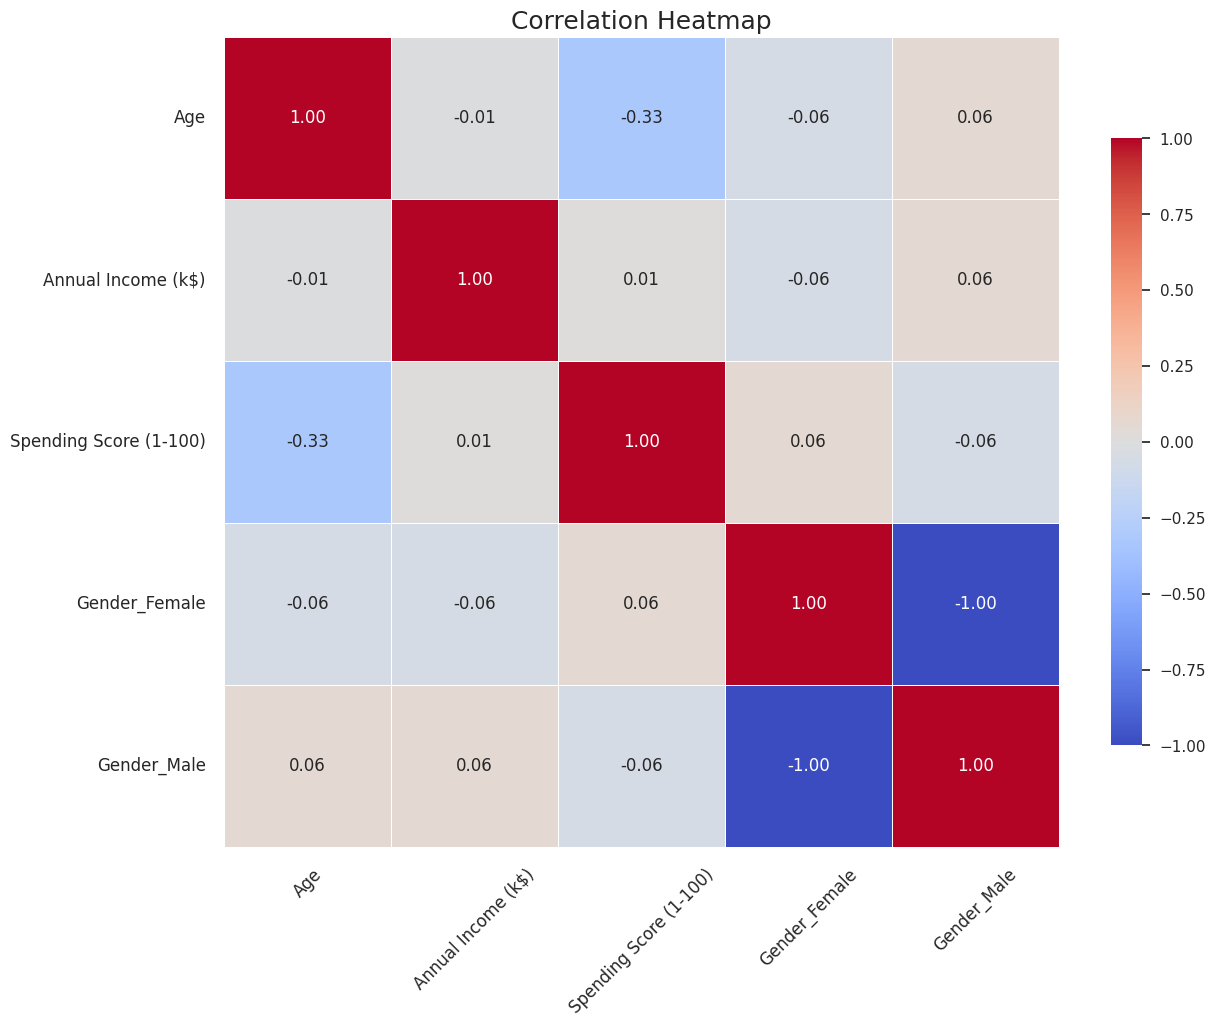

In [23]:
plt.figure(figsize=(12, 10))
heatmap = sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm', linewidths=.5, fmt=".2f", cbar_kws={"shrink": 0.75})
heatmap.set_title('Correlation Heatmap', fontsize=18)
heatmap.set_xticklabels(heatmap.get_xticklabels(), rotation=45, fontsize=12)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0, fontsize=12)
plt.show()

In [24]:
df3 = df.drop(columns=['CustomerID'],axis=1)

In [25]:
df_km=df3.copy(deep=True)
df_km.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = df_km.select_dtypes(include='object').columns
for col in categorical_cols:
    df_km[col] = le.fit_transform(df_km[col])

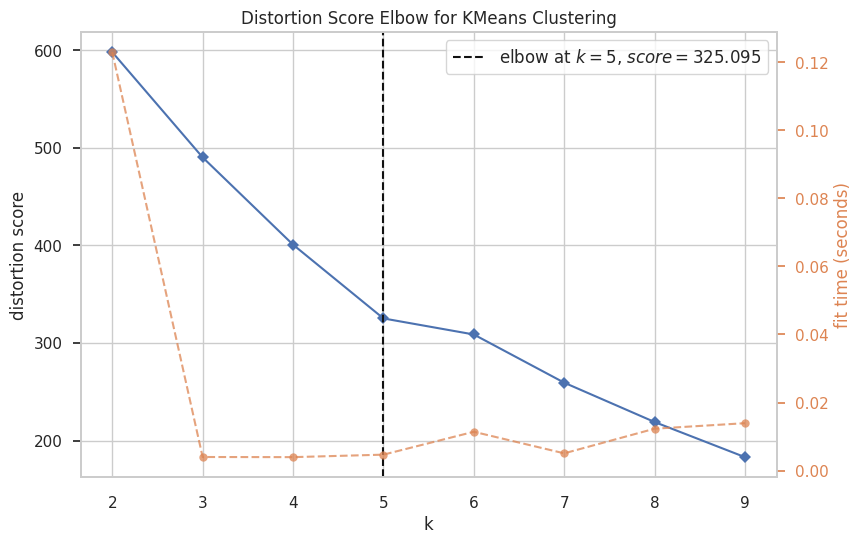

In [27]:
X = df_km
scaler = StandardScaler()
X = scaler.fit_transform(X)
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10))
visualizer.fit(X)
visualizer.show()
plt.show()

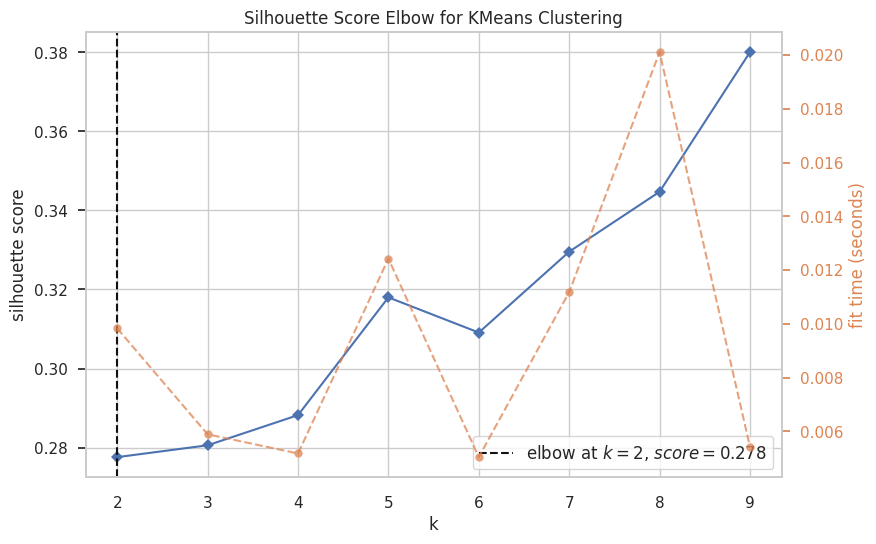

In [28]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette')
visualizer.fit(X)
visualizer.show()
plt.show()

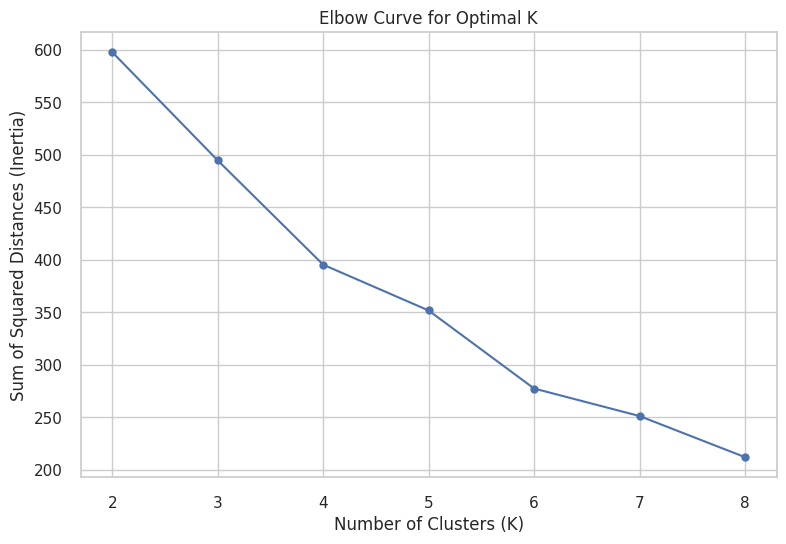

In [29]:
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=42)
    kmeans.fit(X)
    ssd.append(kmeans.inertia_)
plt.plot(range_n_clusters, ssd, marker='o')
plt.title('Elbow Curve for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.show()

In [30]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)

In [31]:
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

In [32]:
df_km['cluster'] = y_kmeans
df_km.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,2
3,0,23,16,77,0
4,0,31,17,40,2


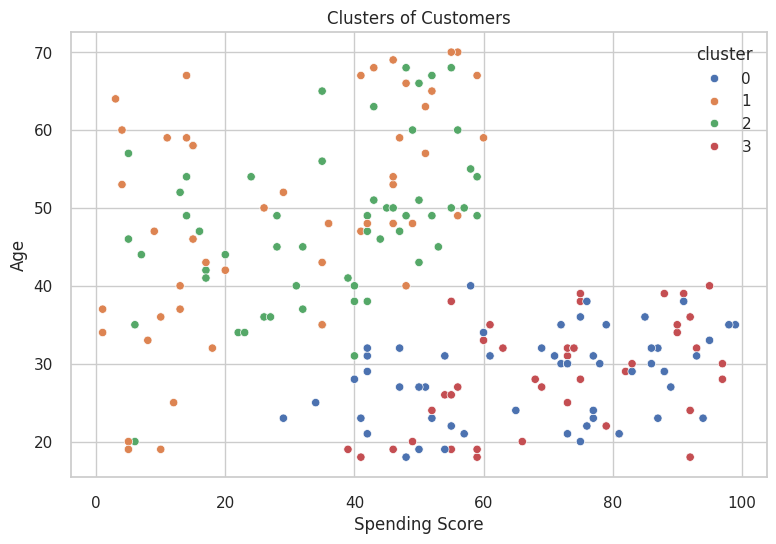

In [33]:
sns.scatterplot(x='Spending Score (1-100)', y='Age', hue='cluster', data=df_km, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Spending Score')
plt.ylabel('Age')
plt.show()

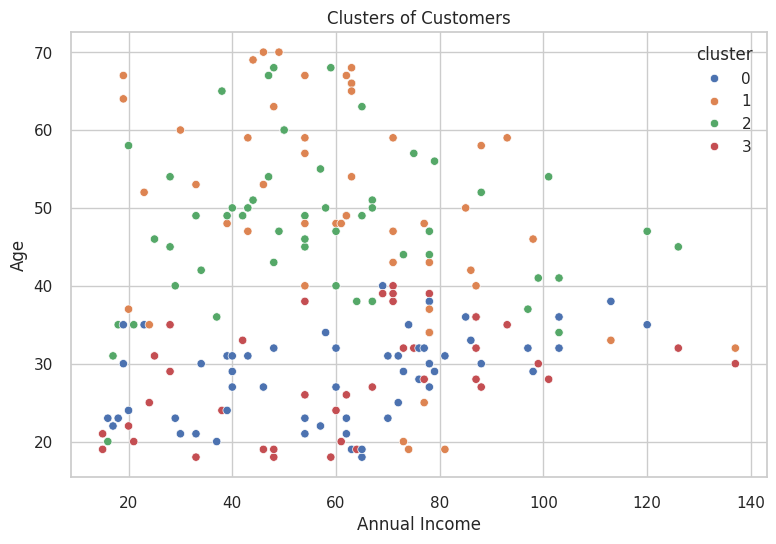

In [34]:
sns.scatterplot(x='Annual Income (k$)', y='Age', hue='cluster', data=df_km, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Age')
plt.show()

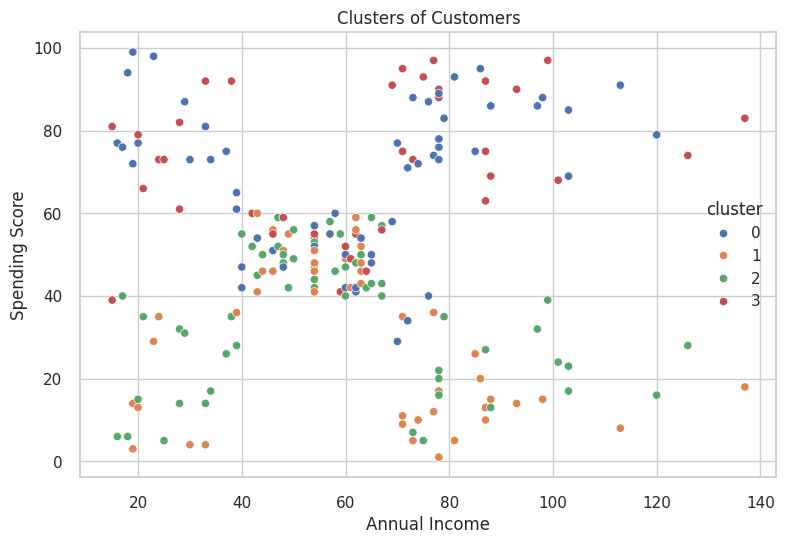

In [35]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=df_km, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

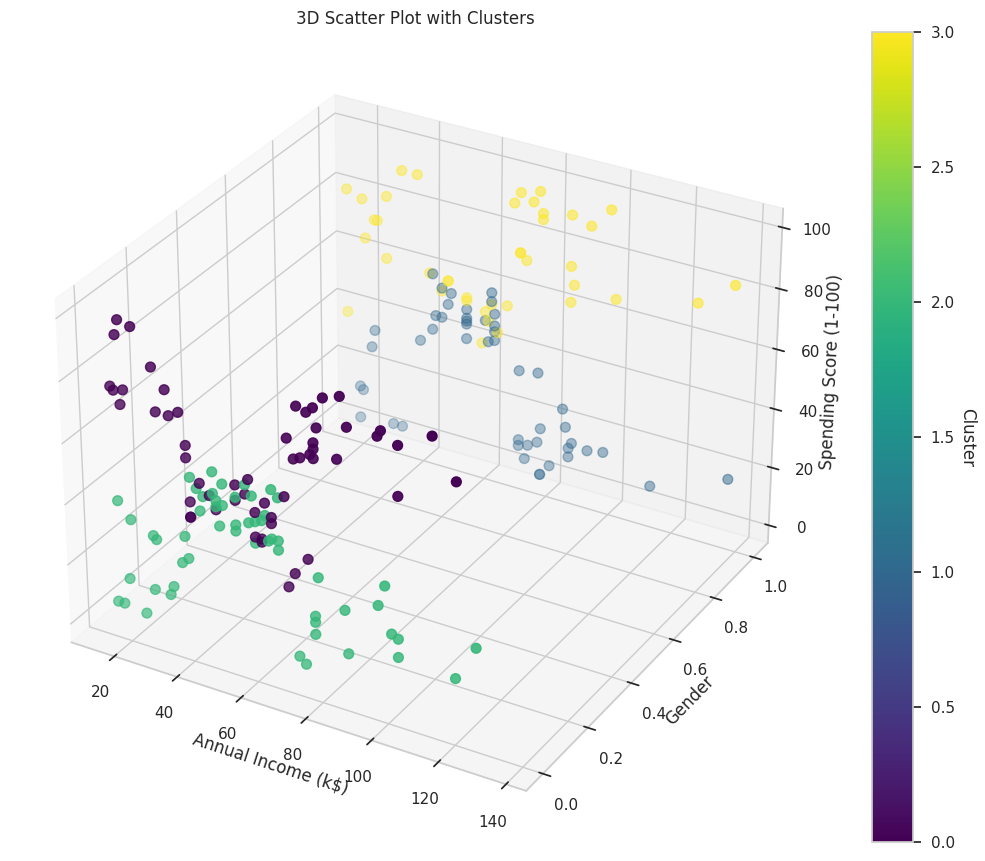

In [36]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_km['Annual Income (k$)'],
            df_km['Gender'],
            df_km['Spending Score (1-100)'],
            c=df_km['cluster'], cmap='viridis', s=50)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Gender')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Scatter Plot with Clusters')
colorbar = plt.colorbar(scatter)
colorbar.set_label('Cluster', rotation=270, labelpad=15)
plt.show()

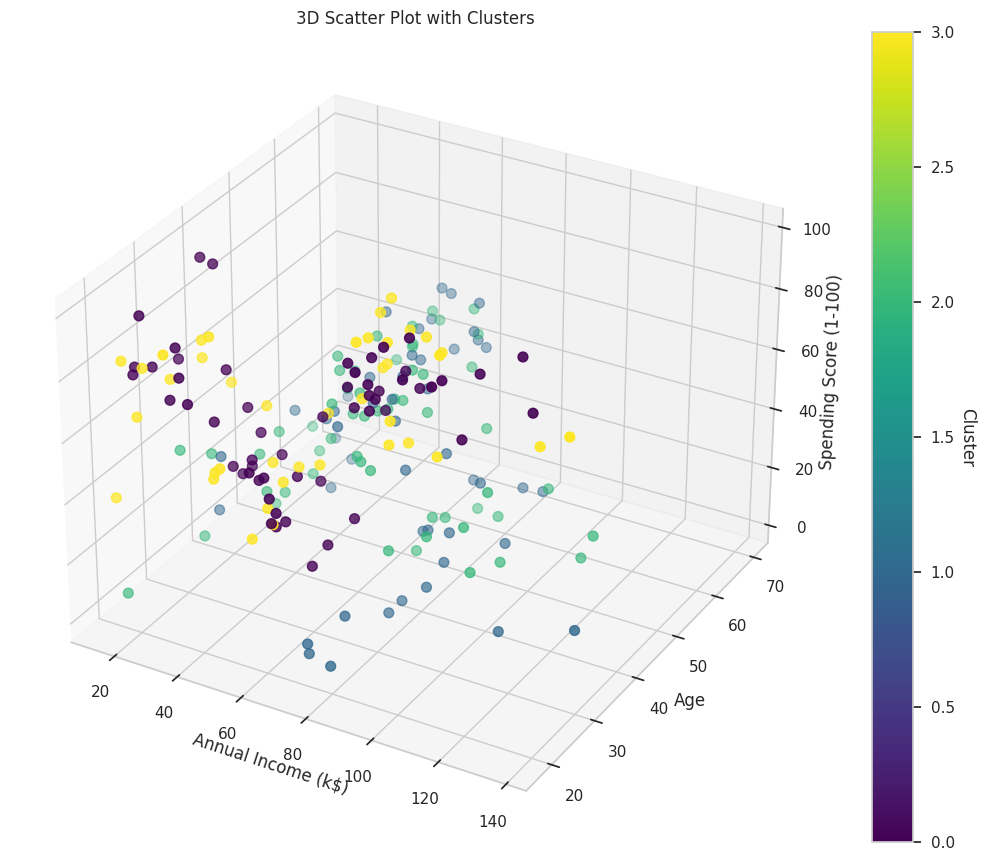

In [37]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_km['Annual Income (k$)'],
            df_km['Age'],
            df_km['Spending Score (1-100)'],
            c=df_km['cluster'], cmap='viridis', s=50)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Age')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Scatter Plot with Clusters')
colorbar = plt.colorbar(scatter)
colorbar.set_label('Cluster', rotation=270, labelpad=15)
plt.show()

In [38]:
df_km.groupby('cluster').describe()

Gender                                      Age             ...  \
         count mean  std  min  25%  50%  75%  max count       mean  ...   
cluster                                                             ...   
0         56.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  56.0  28.392857  ...   
1         48.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  48.0  49.437500  ...   
2         56.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  56.0  47.803571  ...   
3         40.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  40.0  28.250000  ...   

        Annual Income (k$)        Spending Score (1-100)             \
                       75%    max                  count       mean   
cluster                                                               
0                     78.0  120.0                   56.0  68.178571   
1                     78.0  137.0                   48.0  29.208333   
2                     73.5  126.0                   56.0  34.875000   
3                     78.0  137.0                   40.0  71.675000   

                                                    
               std   min    25%   50%    75%   max  
cluster                                             
0        18.502194  29.0  51.75  73.0  83.50  99.0  
1        19.266284   1.0  11.75  32.0  46.25  60.0  
2        16.329630   5.0  21.50  39.5  48.25  59.0  
3        16.727664  39.0  58.25  73.0  88.50  97.0  

[4 rows x 32 columns]

In [39]:
df4 = df.drop(columns=['CustomerID'],axis=1)

In [40]:
df_hr = df4.copy(deep=True)

In [41]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [42]:
categorical_cols = df_hr.select_dtypes(include='object').columns
for col in categorical_cols:
    df_hr[col] = le.fit_transform(df_hr[col])

In [43]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Gender                  200 non-null    int64
 1   Age                     200 non-null    int64
 2   Annual Income (k$)      200 non-null    int64
 3   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4)
memory usage: 6.4 KB


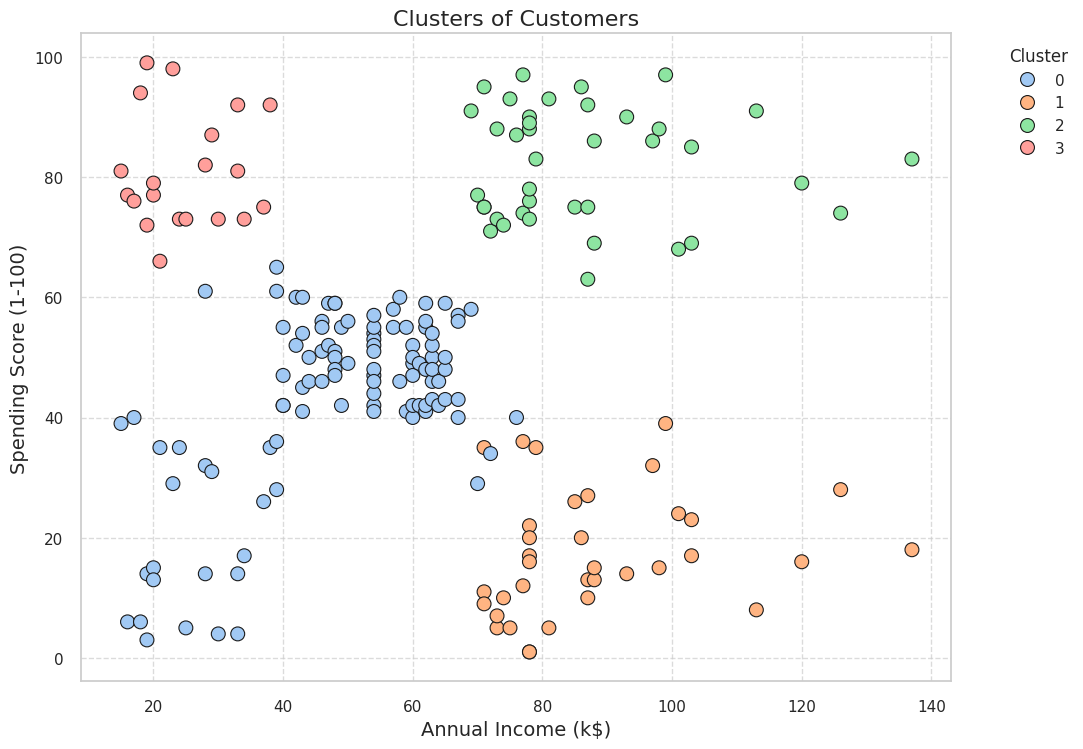

In [44]:
model = AgglomerativeClustering(n_clusters=4)
df_hr['cluster'] = model.fit_predict(df_hr)
cluster_palette = sns.color_palette('pastel', as_cmap=True)

plt.figure(figsize=(10, 8))
scatter = sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='cluster',
    data=df_hr,
    palette=cluster_palette,
    edgecolor='k',
    s=100,
)

plt.title('Clusters of Customers', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=14)
plt.ylabel('Spending Score (1-100)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

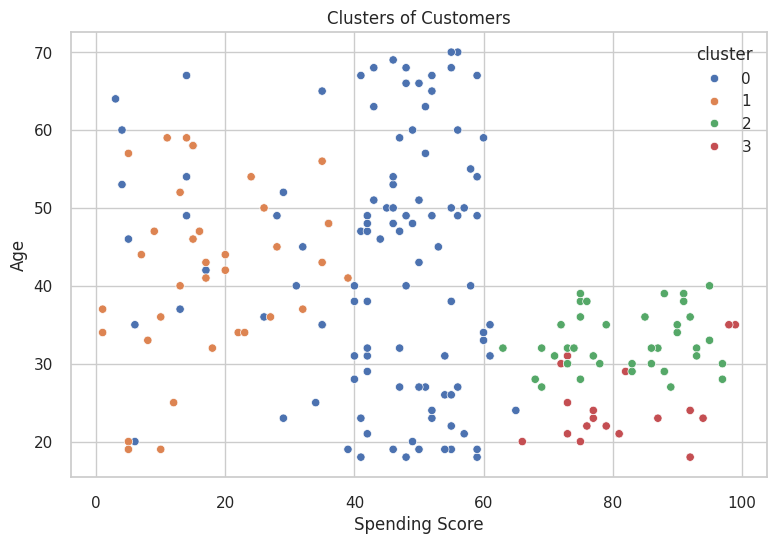

In [45]:
sns.scatterplot(x='Spending Score (1-100)', y='Age', hue='cluster', data=df_hr, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Spending Score')
plt.ylabel('Age')
plt.show()

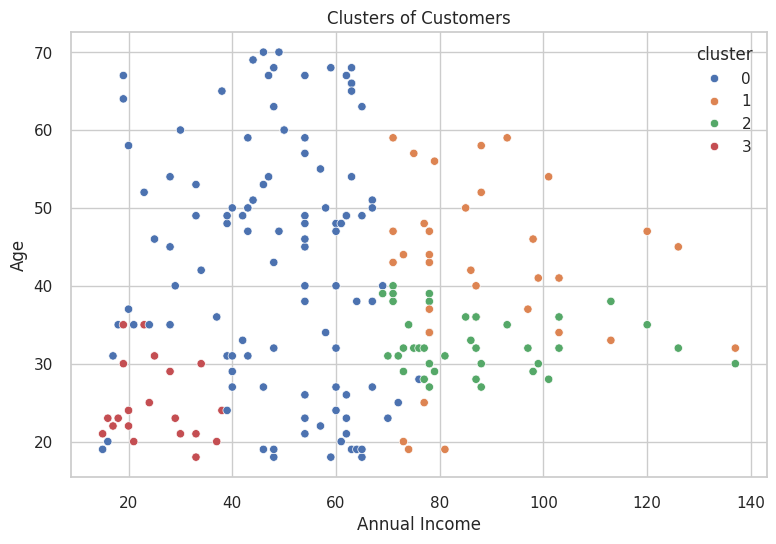

In [46]:
sns.scatterplot(x='Annual Income (k$)', y='Age', hue='cluster', data=df_hr, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Age')
plt.show()

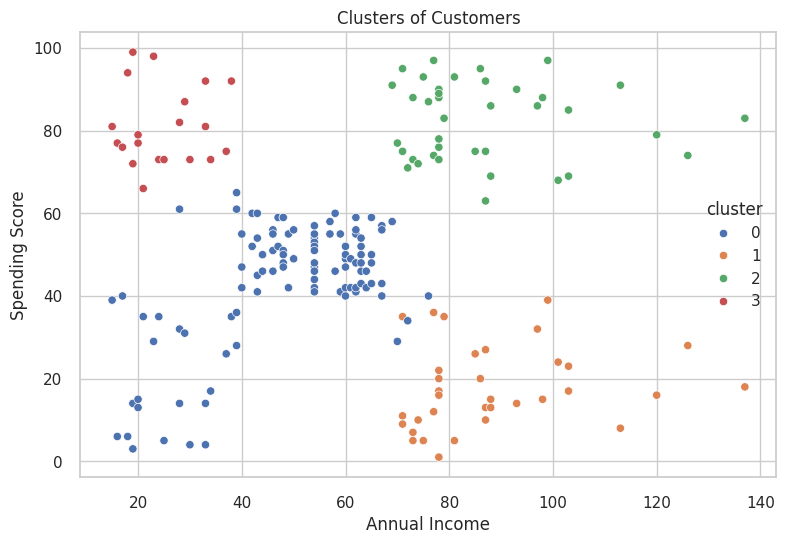

In [47]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=df_hr, palette="deep")
plt.title('Clusters of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

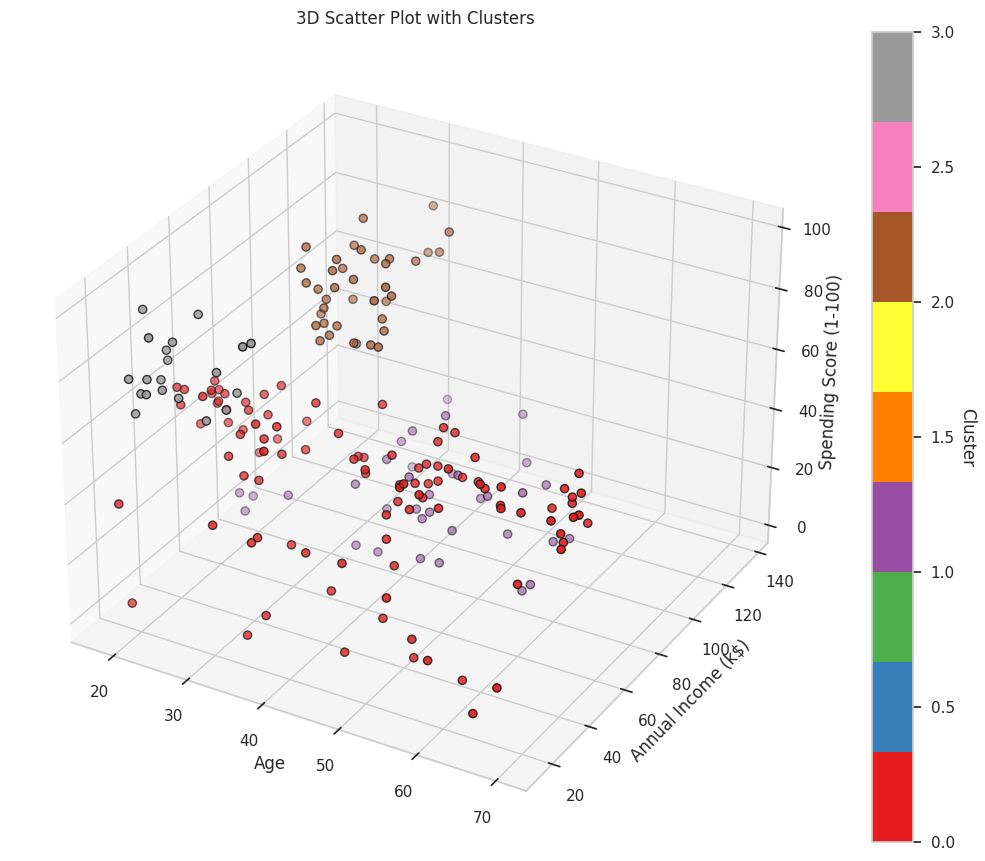

In [48]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_hr['Age'],
           df_hr['Annual Income (k$)'],
           df_hr['Spending Score (1-100)'],
           c=df_hr['cluster'],
           s=35, edgecolor='k', cmap=plt.cm.Set1)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Scatter Plot with Clusters')
colorbar = plt.colorbar(scatter)
colorbar.set_label('Cluster', rotation=270, labelpad=15)
plt.show()

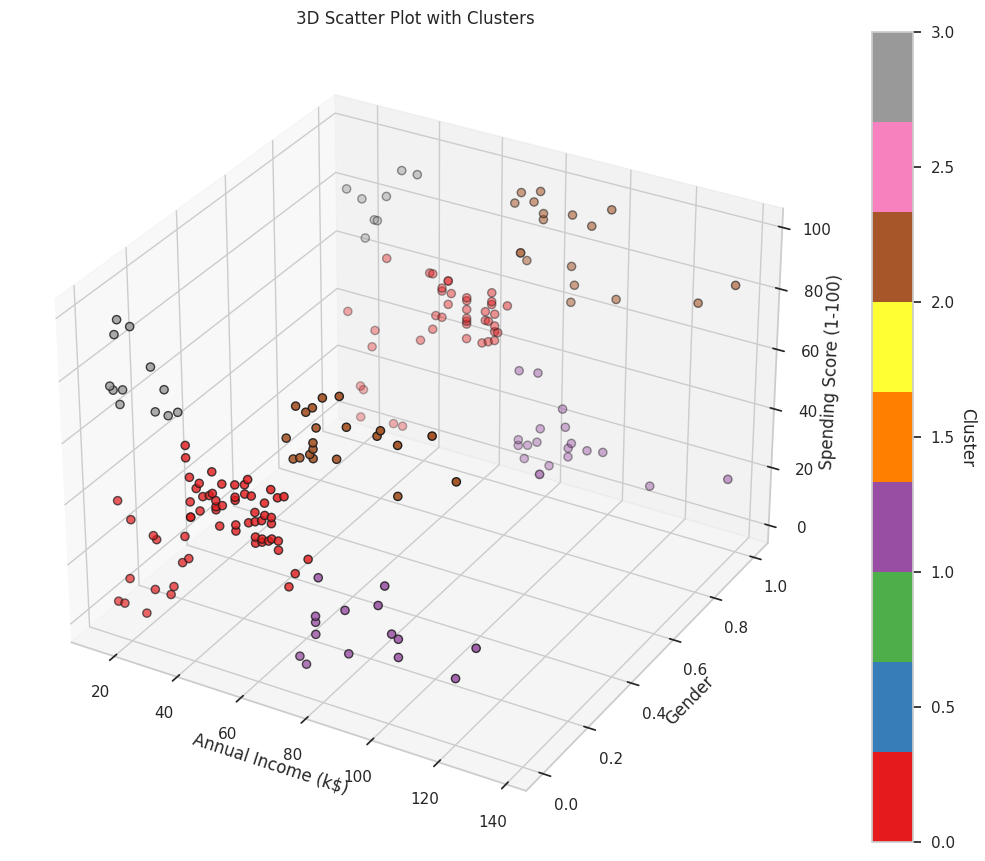

In [49]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_hr['Annual Income (k$)'],
           df_hr['Gender'],
           df_hr['Spending Score (1-100)'],
           c=df_hr['cluster'],
           s=35, edgecolor='k', cmap=plt.cm.Set1)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Gender')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('3D Scatter Plot with Clusters')
colorbar = plt.colorbar(scatter)
colorbar.set_label('Cluster', rotation=270, labelpad=15)
plt.show()